# # 03 — Ad Content Analysis
# 
# **Research Questions:**
# 1. Does seeding shopping history shift the *content* of ads served? (Outcome)
# 2. Which ad networks are *responsible* for category-specific targeting? (Mechanism)
# 3. Is the observed targeting differential statistically significant?
#
# **Inputs:** `artifacts/parquet/ads.parquet` (≈1,668 ads, ~400 with OCR text)
# **Outputs:** `artifacts/figures/03_ad_content/fig10–fig14_*.pdf`

In [2]:
# %% Cell 1: Setup
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

from config import PROFILES, PROFILE_LABELS, PROFILE_COLORS, FIGURES_DIR
from src.utils.db import db_session
from src.analysis.ads import (
    ad_counts_by_profile,
    network_distribution_by_profile,
    categorize_ads_by_keywords,
    network_category_matrix,
    network_category_differential,
)
from src.analysis.statistics import chi_square_batch
from src.viz.ad_plots import (
    apply_style,
    plot_category_comparison,
    plot_network_heatmap,
    plot_network_specialization,
    plot_differential_targeting,
)

apply_style()
FIG_DIR = FIGURES_DIR / "03_ad_content"
FIG_DIR.mkdir(parents=True, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# ## Section 1 — Ad Volume & Network Baseline

In [3]:
# %% Cell 2: Volume & OCR Yield
with db_session(read_only=True) as con:
    summary = con.execute("""
        SELECT 
            profile,
            COUNT(*) AS total_ads,
            COUNT(DISTINCT visit_id) AS visits_with_ads,
            SUM(CASE WHEN ocr_char_count > 10 THEN 1 ELSE 0 END) AS ads_with_text,
            ROUND(100.0 * SUM(CASE WHEN ocr_char_count > 10 THEN 1 ELSE 0 END) 
                  / COUNT(*), 1) AS ocr_yield_pct,
            ROUND(AVG(CASE WHEN ocr_char_count > 10 THEN ocr_char_count END), 1) 
                  AS avg_chars_when_present
        FROM ads
        GROUP BY profile
        ORDER BY profile
    """).df()
print("Ad Volume & OCR Yield:")
print(summary.to_string(index=False))

Ad Volume & OCR Yield:
 profile  total_ads  visits_with_ads  ads_with_text  ocr_yield_pct  avg_chars_when_present
 control        829               82          416.0           50.2                    90.8
shopping        839               79          424.0           50.5                    93.8


In [4]:
# %% Cell 3: Top Ad Networks Across Both Profiles
networks = network_distribution_by_profile(min_confidence='high')
print("\nNetwork distribution:")
print(networks.head(20).to_string(index=False))

top_networks = (networks.groupby('advertiser_network')['n_ads']
                .sum().nlargest(8).index.tolist())
print(f"\nTop 8 networks (used for downstream analysis): {top_networks}")


Network distribution:
 profile advertiser_network  n_ads   pct
 control     google_adsense    451 59.34
 control           gam_slot    199 26.18
 control google_doubleclick     70  9.21
 control            taboola     37  4.87
 control              yahoo      3  0.39
shopping     google_adsense    461 61.63
shopping           gam_slot    176 23.53
shopping google_doubleclick     66  8.82
shopping            taboola     43  5.75
shopping       thetradedesk      2  0.27

Top 8 networks (used for downstream analysis): ['google_adsense', 'gam_slot', 'google_doubleclick', 'taboola', 'yahoo', 'thetradedesk']


# ## Section 2 — Keyword-Based Categorization
# 
# Each OCR'd ad is tagged into one of 5 categories using a lexicon defined in 
# `src/analysis/ads.py`. Ads without enough text fall into `Unknown` and are 
# excluded from category-level statistics.

In [5]:
# %% Cell 4: Categorize All Ads
cat_df = categorize_ads_by_keywords(min_ocr_chars=10)
print("Category distribution by profile:")
print(pd.crosstab(cat_df['profile'], cat_df['ad_category'], margins=True))

Category distribution by profile:
ad_category  Finance  Health  Retail  Tech  Travel  Unknown   All
profile                                                          
control           10       6      49    69       2      624   760
shopping          11       6      22    50       4      655   748
All               21      12      71   119       6     1279  1508


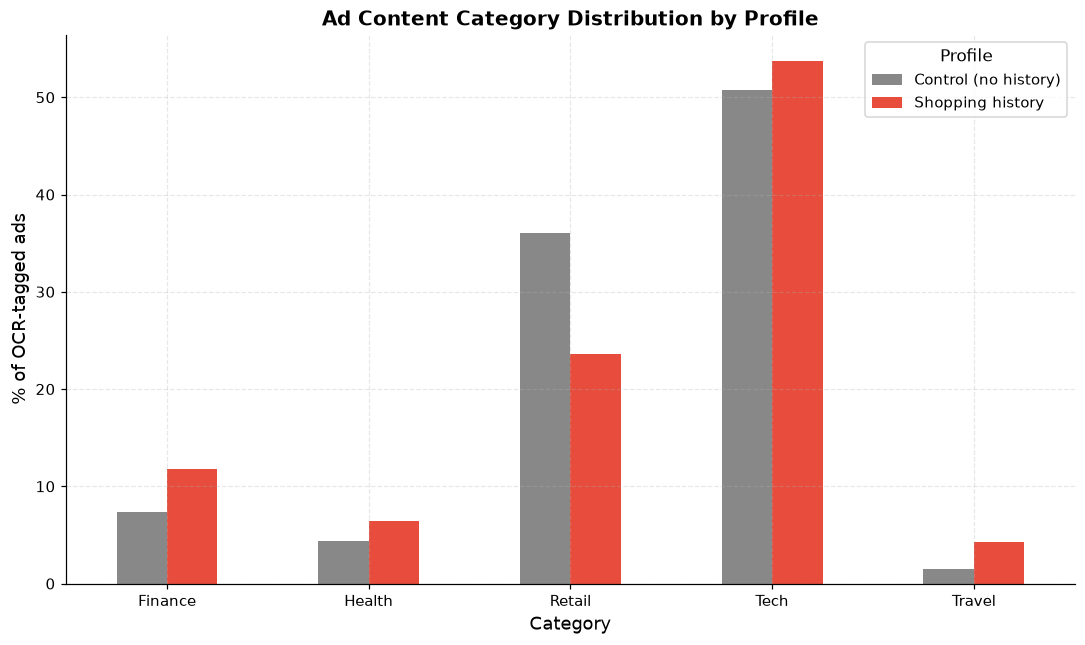

In [6]:
# %% Cell 5: FIGURE 10 — Category Comparison Between Profiles
fig = plot_category_comparison(cat_df, save_path=FIG_DIR / "fig10_ad_categories.pdf")
plt.show()

# ## Section 3 — Statistical Significance (RQ1)
# Chi-square test on each category: shopping vs. control.

In [7]:
# %% Cell 6: Chi-Square Test on Categories
contingency = pd.crosstab(cat_df['profile'], cat_df['ad_category'])
print("Contingency table:")
print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)
print(f"\nOverall χ² = {chi2:.3f}, dof = {dof}, p = {p:.4g}")

# Per-category 2x2 tests (Bonferroni-corrected)
categories = [c for c in contingency.columns if c != 'Unknown']
results = []
for cat in categories:
    table = pd.DataFrame({
        'in_category': contingency[cat],
        'other': contingency.drop(columns=cat).sum(axis=1),
    })
    chi2_c, p_c, _, _ = chi2_contingency(table)
    shopping_rate = table.loc['shopping', 'in_category'] / table.loc['shopping'].sum()
    control_rate = table.loc['control', 'in_category'] / table.loc['control'].sum()
    results.append({
        'category': cat,
        'shopping_pct': round(100 * shopping_rate, 2),
        'control_pct': round(100 * control_rate, 2),
        'lift': round(shopping_rate / control_rate if control_rate > 0 else np.nan, 2),
        'chi2': round(chi2_c, 3),
        'p_value': p_c,
        'p_bonferroni': min(1.0, p_c * len(categories)),
    })
stats_df = pd.DataFrame(results).sort_values('p_value')
print("\nPer-category results (Bonferroni-corrected):")
print(stats_df.to_string(index=False))
stats_df.to_csv(FIG_DIR / "table_category_stats.csv", index=False)

Contingency table:
ad_category  Finance  Health  Retail  Tech  Travel  Unknown
profile                                                    
control           10       6      49    69       2      624
shopping          11       6      22    50       4      655

Overall χ² = 14.672, dof = 5, p = 0.01186

Per-category results (Bonferroni-corrected):
category  shopping_pct  control_pct  lift  chi2  p_value  p_bonferroni
  Retail          2.94         6.45  0.46 9.563 0.001986      0.009929
    Tech          6.68         9.08  0.74 2.653 0.103336      0.516681
  Travel          0.53         0.26  2.03 0.184 0.668209      1.000000
 Finance          1.47         1.32  1.12 0.001 0.970705      1.000000
  Health          0.80         0.79  1.02 0.000 1.000000      1.000000


# ## Section 4 (Frame 2) — Network × Category Mechanism Analysis
# 
# **Goal:** Identify *which networks* are responsible for category-specific 
# targeting. We compute:
# 1. A network × category matrix per profile (raw counts and row-normalized %)
# 2. A "specialization index" per network (entropy-based: low = specialist, high = generalist)
# 3. A differential matrix: shopping_share − control_share per (network, category)
#    → highlights *which network drove the targeting shift*

In [8]:
# %% Cell 7: Network × Category Matrices
net_cat_shopping = network_category_matrix(
    cat_df, profile='shopping', top_networks=top_networks, normalize='row'
)
net_cat_control = network_category_matrix(
    cat_df, profile='control', top_networks=top_networks, normalize='row'
)
print("Shopping profile — network × category (% of each network's ads):")
print(net_cat_shopping.round(1))
print("\nControl profile — network × category (% of each network's ads):")
print(net_cat_control.round(1))


Shopping profile — network × category (% of each network's ads):
ad_category         Finance  Health  Retail  Tech  Travel
advertiser_network                                       
google_adsense          8.9     3.6    30.4  53.6     3.6
gam_slot                7.7     0.0     0.0  76.9    15.4
google_doubleclick     50.0     0.0     0.0  50.0     0.0
taboola                15.0    20.0    25.0  40.0     0.0
yahoo                   0.0     0.0     0.0   0.0     0.0
thetradedesk            0.0     0.0     0.0   0.0     0.0

Control profile — network × category (% of each network's ads):
ad_category         Finance  Health  Retail  Tech  Travel
advertiser_network                                       
google_adsense          3.1     3.1    27.7  63.1     3.1
gam_slot                4.8     0.0    38.1  57.1     0.0
google_doubleclick      0.0     0.0    72.7  27.3     0.0
taboola                24.0    16.0    20.0  40.0     0.0
yahoo                  33.3     0.0    66.7   0.0     0.0


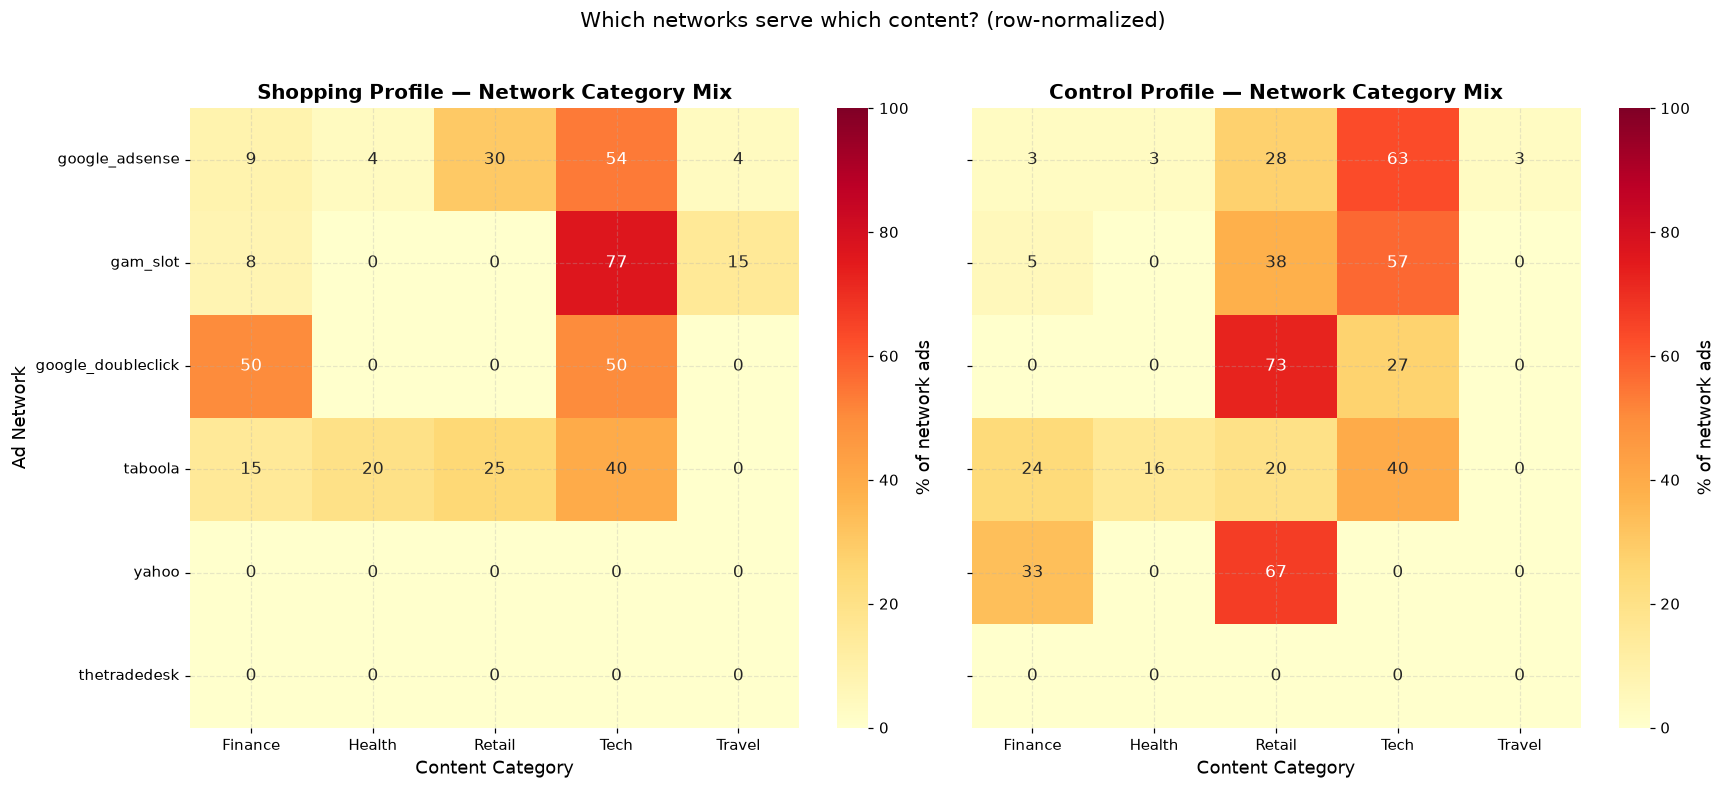

In [9]:
# %% Cell 8: FIGURE 11 — Side-by-Side Network × Category Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
sns.heatmap(net_cat_shopping, annot=True, fmt=".0f", cmap="YlOrRd",
            vmin=0, vmax=100, ax=axes[0], cbar_kws={'label': '% of network ads'})
axes[0].set_title("Shopping Profile — Network Category Mix", fontweight='bold')
axes[0].set_xlabel("Content Category")
axes[0].set_ylabel("Ad Network")

sns.heatmap(net_cat_control, annot=True, fmt=".0f", cmap="YlOrRd",
            vmin=0, vmax=100, ax=axes[1], cbar_kws={'label': '% of network ads'})
axes[1].set_title("Control Profile — Network Category Mix", fontweight='bold')
axes[1].set_xlabel("Content Category")
axes[1].set_ylabel("")

plt.suptitle("Which networks serve which content? (row-normalized)", 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig11_network_category_heatmap.pdf", bbox_inches='tight')
plt.show()

Differential (shopping% − control%) by network and category:
ad_category         Finance  Health  Retail  Tech  Travel
advertiser_network                                       
google_adsense          5.9     0.5     2.7  -9.5     0.5
gam_slot                2.9     0.0   -38.1  19.8    15.4
google_doubleclick     50.0     0.0   -72.7  22.7     0.0
taboola                -9.0     4.0     5.0   0.0     0.0
yahoo                 -33.3     0.0   -66.7   0.0     0.0
thetradedesk            0.0     0.0     0.0   0.0     0.0


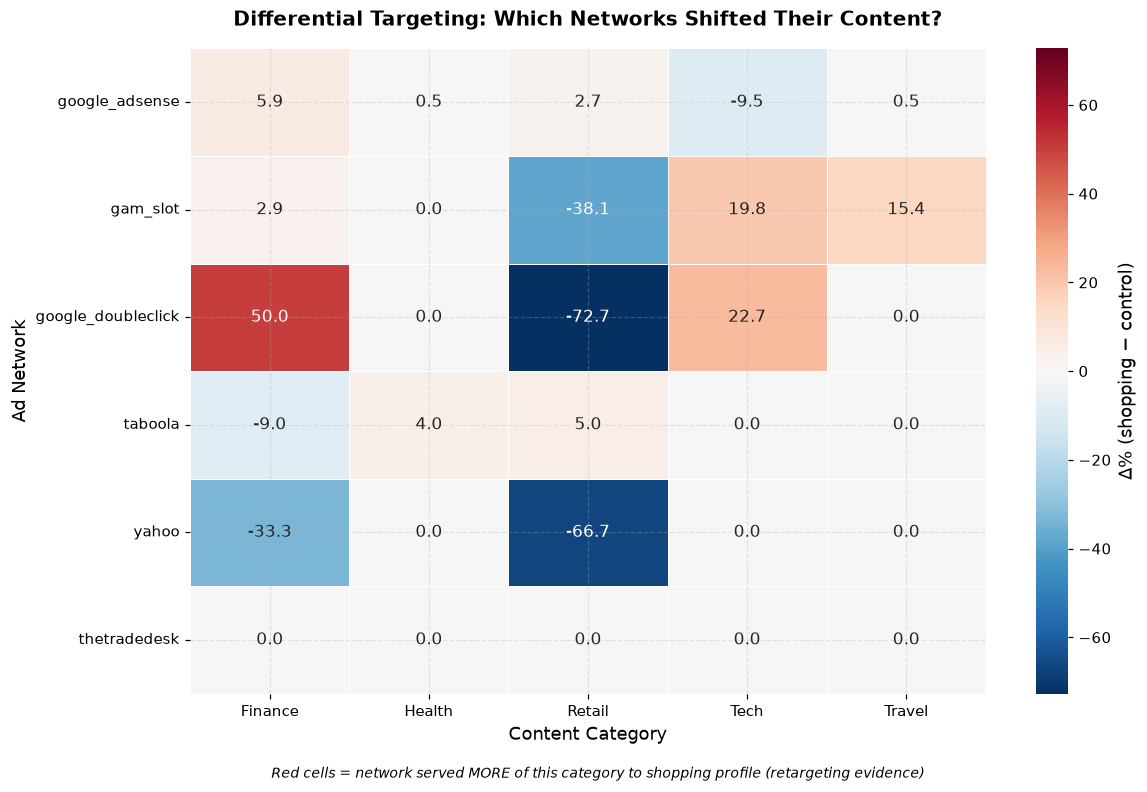

In [10]:
# %% Cell 9: FIGURE 12 — Differential Targeting Heatmap (THE KEY FIGURE)
# Shows: which (network, category) pairs surged in the shopping profile?
diff_matrix = network_category_differential(cat_df, top_networks=top_networks)
print("Differential (shopping% − control%) by network and category:")
print(diff_matrix.round(1))

fig = plot_differential_targeting(
    diff_matrix,
    save_path=FIG_DIR / "fig12_differential_targeting.pdf"
)
plt.show()

# **Reading fig12:** Positive (red) cells show that the network served *more* of 
# that category to the shopping profile than the control. Negative (blue) cells 
# show suppression. A strong red cell at (Criteo, Retail) is direct evidence of 
# behavioral retargeting *attributable to that specific network*.

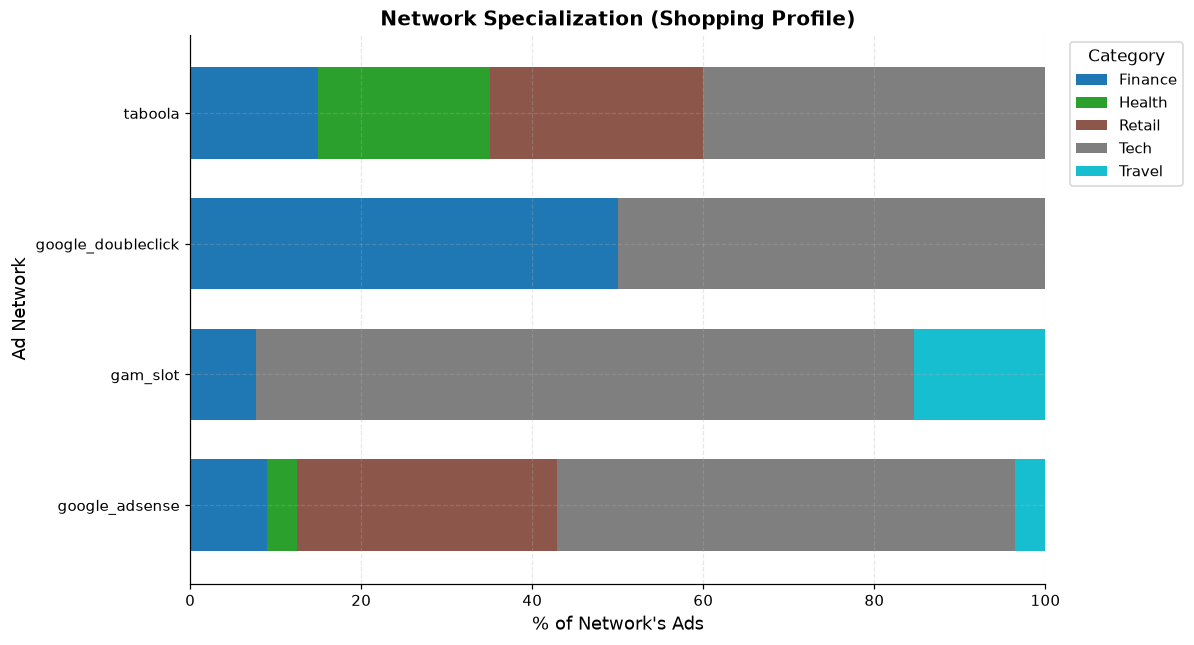

In [11]:
# %% Cell 10: FIGURE 13 — Network Specialization Profile
# Entropy-based: networks concentrated in 1-2 categories are "specialists"
fig = plot_network_specialization(
    cat_df, top_networks=top_networks,
    save_path=FIG_DIR / "fig13_network_specialization.pdf"
)
plt.show()

# ## Section 5 — Per-Network Chi-Square (RQ2)
# For each top network, test whether its category mix differs significantly 
# between shopping and control profiles.


In [12]:
# %% Cell 11: Per-Network Significance Tests
network_results = []
for net in top_networks:
    sub = cat_df[(cat_df['advertiser_network'] == net) & 
                 (cat_df['ad_category'] != 'Unknown')]
    if len(sub) < 20:
        continue  # skip low-power tests
    table = pd.crosstab(sub['profile'], sub['ad_category'])
    if table.shape[0] < 2 or table.shape[1] < 2:
        continue
    chi2_n, p_n, dof_n, _ = chi2_contingency(table)
    network_results.append({
        'network': net,
        'n_ads': len(sub),
        'chi2': round(chi2_n, 3),
        'dof': dof_n,
        'p_value': p_n,
        'p_bonferroni': min(1.0, p_n * len(top_networks)),
        'verdict': '✅ Significant shift' if p_n * len(top_networks) < 0.05 
                   else '➖ No significant shift',
    })
network_stats = pd.DataFrame(network_results).sort_values('p_value')
print("Per-network category-shift tests (Bonferroni-corrected):")
print(network_stats.to_string(index=False))
network_stats.to_csv(FIG_DIR / "table_network_stats.csv", index=False)


Per-network category-shift tests (Bonferroni-corrected):
           network  n_ads   chi2  dof  p_value  p_bonferroni                verdict
google_doubleclick     26 14.477    2 0.000718      0.004310    ✅ Significant shift
          gam_slot     34  8.786    3 0.032277      0.193665 ➖ No significant shift
    google_adsense    121  2.362    4 0.669476      1.000000 ➖ No significant shift
           taboola     45  0.675    3 0.879068      1.000000 ➖ No significant shift


# ## Section 6 — Qualitative Gallery: Top Retargeting Evidence

In [13]:
# %% Cell 12: Top Retail Ads in Shopping Profile (for paper appendix)
with db_session(read_only=True) as con:
    top_retail = con.execute("""
        SELECT advertiser_network, page_url, ocr_text, ocr_char_count
        FROM ads
        WHERE profile = 'shopping'
          AND confidence = 'high'
          AND ocr_char_count > 20
          AND regexp_matches(lower(ocr_text), 'shop|sale|buy|discount|shipping|cart|% off')
        ORDER BY ocr_char_count DESC
        LIMIT 15
    """).df()
print("Top 15 retail ads served to the shopping profile:")
for _, row in top_retail.iterrows():
    print(f"\n[{row['advertiser_network']}] on {row['page_url'][:60]}")
    print(f"  OCR: {row['ocr_text'][:200]}...")

top_retail.to_csv(FIG_DIR / "table_top_retail_ads.csv", index=False)

Top 15 retail ads served to the shopping profile:

[taboola] on https://www.ynet.co.il/home/0,7340,L-8,00.html
  OCR: ‘Amazon's Worst Nightmare - Shoppers Are Canceling Prime for This Clever Hack This simple extension tool can save tons of money on Amazon, but most _prime members are ignoring it 1n1n | Online Shoppin...

[taboola] on https://13wham.com/
  OCR: Take every major type of payment | Added This High-Risk Biotech To My _Create your Website In Minutes, with Square Stand Watchlist [See my reasoning] Website Building + Free Domain sPoNsoRED sponsoneo...

[google_adsense] on https://www.aol.com/
  OCR: Furniture You'll Love Mechanics Warn: An Extended Auto Warranty Is Worth It If Your Car Brand Is One Of These hley-Ad Forbes: Ad Style That Fits You Top Urologists: Final Generic Viagra Men Are Rushin...

[taboola] on https://13wham.com/
  OCR: Police: Innocent woman Killed in Suspect arrested for shooting Man in critical condition after targeted gas station ambush employee at Roch

# ## Section 7 — Summary for Paper
# 
# **Key findings to highlight:**
# 1. Overall χ² result from Cell 6
# 2. Categories with significant lift (Cell 6 table) 
# 3. Networks driving the shift (Cell 11 table)
# 4. Specific (network, category) pairs from fig12 — the smoking gun